In [16]:
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import sys
sys.path.append('../')
from src.config import DATA_PRO, MODELS_DIR
FIGURES_DIR = Path('../reports/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [17]:
df = pd.read_csv(DATA_PRO / 'clustered_jobs.csv')
mod = pickle.load(open(MODELS_DIR / 'recommender.pkl', 'rb'))
vecs = mod['vecs']
labels = df['cluster']

In [18]:
sil_score = silhouette_score(vecs, labels)
print(f"Silhouette Score: {sil_score:.3f}")

Silhouette Score: 0.779


Saved PCA plot to E:\smarthire\reports\figures


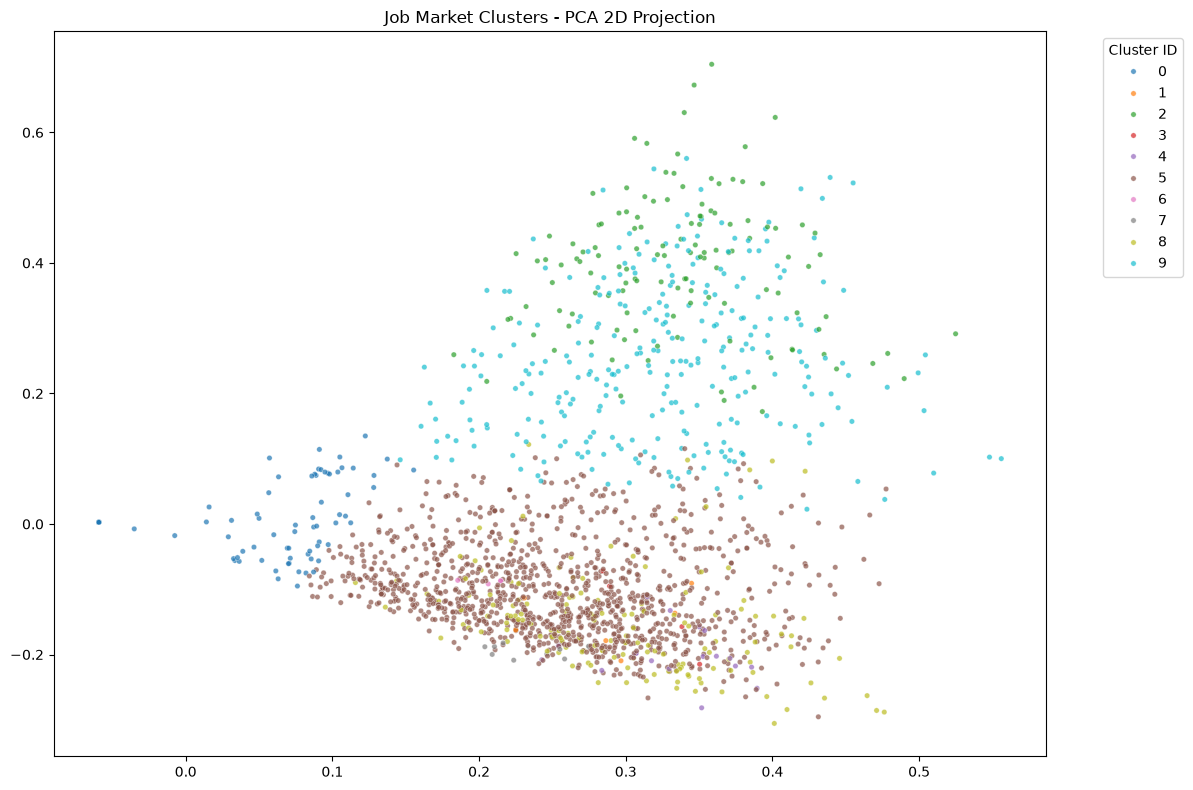

In [19]:
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(vecs.toarray())
plt.figure(figsize=(12, 8))
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=labels, palette='tab10', s=15, alpha=0.7)
plt.title('Job Market Clusters - PCA 2D Projection')
plt.legend(title='Cluster ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pca_clusters.png', dpi=300)
print(f"Saved PCA plot to {FIGURES_DIR.resolve()}")
plt.show()

In [20]:
print("Top Industry Themes Extracted via NMF:")
words = mod['tfidf'].get_feature_names_out()
for i, topic in enumerate(mod['nmf'].components_):
    theme_words = [words[i] for i in topic.argsort()[:-6:-1]]
    print(f"Theme {i+1}: {', '.join(theme_words)}")

Top Industry Themes Extracted via NMF:
Theme 1: work, business, team, management, experience
Theme 2: software, doctorate, profile, programming, description
Theme 3: data, sql, business, analytics, experience
Theme 4: experience, cloud, development, security, software
Theme 5: ai, chatbots, work, javascript, code
